Cannot show ipywidgets in text

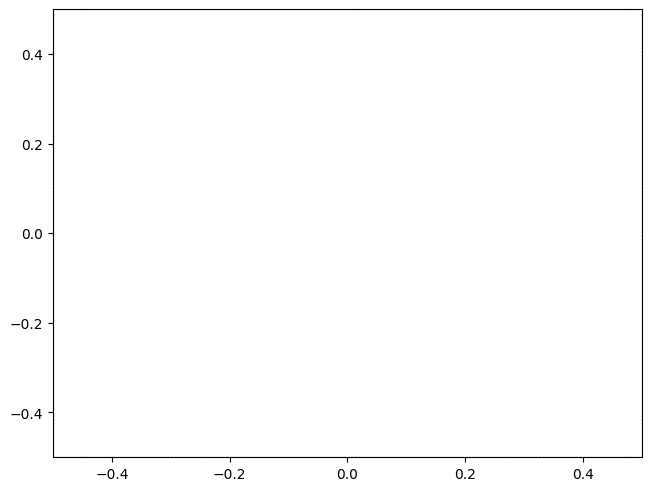

In [8]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa import batch_run
import numpy as np
import sys

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    # Variables

    "V": 0,
    "M_A": 0,
    # TODO: M_A at t=1 is actually not defined. but setting 0 is justified?

    # prior tendencies for neutral behavior
    "theta_N_w0": 3.892,  # should yield around 95% neutral in the beginning
    "theta_N_w1": 0,

    # prior tendencies for friendly behavior
    "theta_F_w0": 0,
    "theta_F_w1": 0,

    # prior tendencies for aggressive behavior
    "theta_A_w0": 0,
    "theta_A_w1": {
        "type": "SliderInt",
        "value": -10,
        "max": 0,
        "min": -100,
    },

    # Some variables will be calculated in the model
    # or received from the environment
    "p_N": None,
    "p_A": None,
    "p_F": None,
    "r": None,
    "rpe": None,

    # Parameters

    # Parameter for the exponential moving average of anger
    "lambda_A": 0.60,

    # Controllability
    "C": {
        "type": "SliderFloat",
        "value":1,
        "max": 1,
        "min": 0,
    }
}

init_variables["theta_N"] = init_variables["theta_N_w0"]

init_variables["theta_F"] = init_variables["theta_F_w0"]

init_variables["theta_A"] = init_variables["theta_A_w0"] + init_variables[
    "theta_F_w1"
] * init_variables["M_A"]

# Create proper parameter dictionary (without the sliders ...)
init_variables_copy = init_variables
init_variables_copy["theta_A_w1"] = init_variables["theta_A_w1"]["value"]
init_variables_copy["theta_A"] = init_variables["theta_A"]
init_variables_copy["C"] = init_variables["C"]["value"]

starter_model = model.IrritabilityModel(seed=12345,
                                        **init_variables_copy)

renderer = SpaceRenderer(model=starter_model, backend="matplotlib").render(
    agent_portrayal=model.IrritabilityModel.agent_portrayal
)

AngerPlot = make_plot_component("M_A", page=1)

page = SolaraViz(
    starter_model,
    renderer,
    components=[AngerPlot],
    model_params=init_variables,
    name="Irritability Model",
)

page